# SMS Spam Detection (NLP) — End-to-End Project  
**Course:** Artificial Intelligence Applications  

---

## Introduction

Spam messages are unsolicited SMS communications that often contain fraudulent promotions, phishing attempts, or malicious links. As mobile communication continues to grow globally, automated spam detection has become a critical real-world application of Artificial Intelligence.

Traditional rule-based filtering systems are limited because spam messages constantly evolve in wording, structure, and tactics. Static keyword matching is insufficient to handle contextual variations, slang, and creative manipulation of text. Therefore, intelligent systems based on **Natural Language Processing (NLP)** and machine learning are required to effectively identify spam patterns.

In this project, we develop an end-to-end NLP-based classification system that automatically categorizes SMS messages as:

- **Spam** (unsolicited or malicious messages)
- **Ham** (legitimate messages)

The problem is formulated as a **supervised text classification task**, where labeled SMS data is used to train machine learning models capable of generalizing to unseen messages.

---

## Project Objective

The main objectives of this project are to:

- Load and explore the SMS spam dataset  
- Perform text preprocessing and feature engineering  
- Convert raw text into numerical representations using **TF-IDF vectorization**  
- Train and compare multiple machine learning classifiers  
- Evaluate performance using metrics such as:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC
- Select the best-performing model
- Save the trained model for simple deployment

---

## Workflow Overview

This notebook follows a structured AI development pipeline:

1. Data Loading  
2. Exploratory Data Analysis (EDA)  
3. Text Preprocessing  
4. Feature Extraction  
5. Model Training  
6. Model Evaluation  
7. Model Selection  
8. Model Saving and Deployment Preparation  

The goal is not only to achieve strong predictive performance but also to build a clean, reproducible, and deployment-ready AI solution.

## 1. Setup
Install requirements

```bash
pip install pandas numpy scikit-learn matplotlib joblib
```


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

import joblib

DATA_PATH = 'data/sms_spam.csv'
FIG_DIR = 'figs'
MODEL_DIR = 'models'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


## 2. Load dataset
The dataset is stored locally in `data/sms_spam.csv` with columns:
- `label`: ham/spam
- `text`: raw SMS message


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = '/content/drive/MyDrive/SMSSpamCollection'
df = pd.read_csv(DATA_PATH, sep='\t', header=None, names=['label', 'text'])
df.head()

#  to see the contents of Drive and verify the exact filename.
import os
print(os.listdir('/content/drive/MyDrive/'))

['How to get started with Drive.pdf', 'Olateju[1].docx', 'Reference letter 2.pdf', 'MotoHub', 'Untitled form (3).gform', 'Report.pdf', 'New Recording.m4a', 'Presale Inspection Presentation.mov', '26790B99-139C-42A3-B865-E209F9FF3C00.mp4', '3A93EFD9-0D71-4B3B-B27D-3429503CC7F4.mp4', 'video-output-727EECA7-B3EA-4FEA-BABF-F75777F4893D.mov', 'CV Malachi I.O(1)-converted.pdf', 'IMG_4653.HEIC', 'IMG_4652.HEIC', 'IMG_4651.HEIC', 'B.Eng Result-compressed.pdf', 'Cover Letter -Malachi Idowu Oluwadamilola.pdf', 'certificate.pdf', 'SSCE Result.pdf', 'Transcript- Malachi Idowu Oluwadamilola .pdf', 'Contact Information.gform', 'Untitled form (2).gform', 'Untitled form (1).gform', 'MotoMarket Ltd - Approval for Expense (File responses)', 'printrecieptRequest.pdf', 'Approval for Expense (Responses).gsheet', 'motomarket (1).xls', 'motomarket.xls', 'ATAS_certificate.pdf', 'Reference letter - Malachi Idowu Oluwadamilola.gdoc', 'Reference letter - Malachi Idowu Oluwadamilola.docx', 'Reference Cover Letter

In [4]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


### Basic feature engineering for EDA
We will compute message length in characters and in words.


In [5]:
df['char_len'] = df['text'].astype(str).str.len()
df['word_len'] = df['text'].astype(str).str.split().str.len()
df.describe(include='all')

,label,text,char_len,word_len
count,5572,5572,5572.000000,5572.000000
unique,2,5169,NaN,NaN
top,ham,"Sorry, I'll call later",NaN,NaN
freq,4825,30,NaN,NaN
mean,NaN,NaN,80.489950,15.597452
std,NaN,NaN,59.942907,11.404053
min,NaN,NaN,2.000000,1.000000
25%,NaN,NaN,36.000000,7.000000
50%,NaN,NaN,62.000000,12.000000
75%,NaN,NaN,122.000000,23.000000


## 3. Exploratory Data Analysis (EDA)
### 3.1 Class distribution


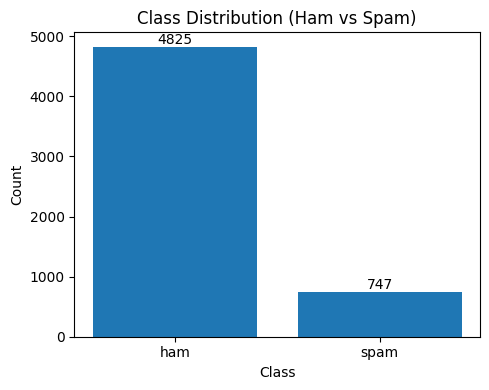

In [6]:
counts = df['label'].value_counts().reindex(['ham','spam'])
plt.figure(figsize=(5,4))
plt.bar(counts.index, counts.values)
plt.title('Class Distribution (Ham vs Spam)')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.png'), dpi=200)
plt.show()

### 3.2 Message length distribution
Spam messages tend to be longer on average (often containing offers, links, or call-to-action text).


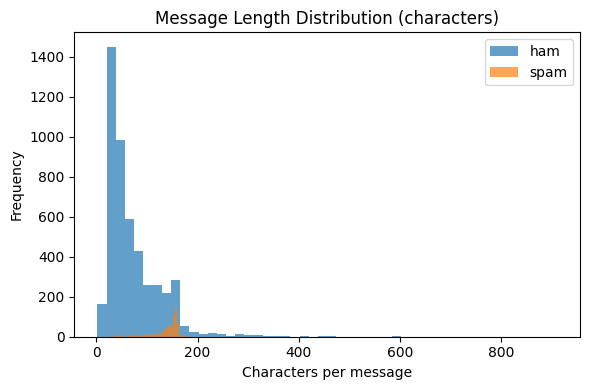

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df.loc[df.label=='ham','char_len'], bins=50, alpha=0.7, label='ham')
plt.hist(df.loc[df.label=='spam','char_len'], bins=50, alpha=0.7, label='spam')
plt.title('Message Length Distribution (characters)')
plt.xlabel('Characters per message')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'length_distribution_chars.png'), dpi=200)
plt.show()

/tmp/ipython-input-224/1326244915.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


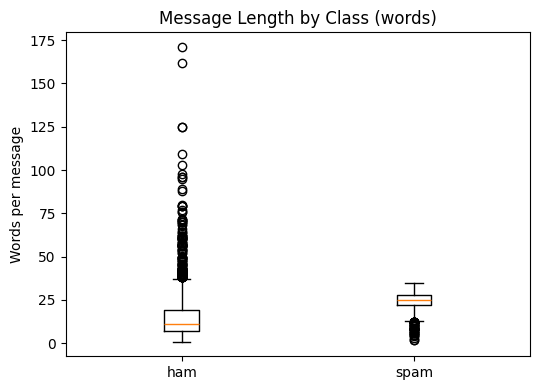

In [8]:
plt.figure(figsize=(5.5,4))
plt.boxplot([
    df.loc[df.label=='ham','word_len'],
    df.loc[df.label=='spam','word_len']
], labels=['ham','spam'])
plt.title('Message Length by Class (words)')
plt.ylabel('Words per message')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'length_boxplot_words.png'), dpi=200)
plt.show()

## 4. Train/test split
We use a stratified split to preserve the ham/spam ratio.


In [9]:
X = df['text'].astype(str).values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', len(X_train), 'Test:', len(X_test))


Train: 4457 Test: 1115


## 5. Baseline
A simple baseline is predicting the majority class (ham) for all messages.


In [10]:
majority = pd.Series(y_train).mode()[0]
y_pred_base = np.array([majority]*len(y_test))
print('Baseline majority class:', majority)
print(classification_report(y_test, y_pred_base))

Baseline majority class: ham
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       966
        spam       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6. Modeling approach
We use:
- **TF-IDF** to convert text into numeric features
- Several classic classifiers for text: Multinomial Naive Bayes, Logistic Regression, Linear SVM

We evaluate using **5-fold cross-validation** (macro-averaged metrics) and then a final test set.


In [11]:
models = {
    'MultinomialNB (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english')),
        ('clf', MultinomialNB(alpha=0.5))
    ]),
    'Logistic Regression (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
    ]),
    'Linear SVM (TF-IDF)': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)),
        ('clf', LinearSVC(class_weight='balanced'))
    ])
}


### 6.1 Cross-validation


In [12]:
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    rows.append({
        'Model': name,
        'CV Accuracy (mean)': scores['test_accuracy'].mean(),
        'CV F1-macro (mean)': scores['test_f1_macro'].mean(),
        'CV Precision-macro (mean)': scores['test_precision_macro'].mean(),
        'CV Recall-macro (mean)': scores['test_recall_macro'].mean(),
    })
cv_df = pd.DataFrame(rows).sort_values('CV F1-macro (mean)', ascending=False)
cv_df

,Model,CV Accuracy (mean),CV F1-macro (mean),CV Precision-macro (mean),CV Recall-macro (mean)
2,Linear SVM (TF-IDF),0.983396,0.963560,0.972695,0.955055
1,Logistic Regression (TF-IDF),0.980929,0.958847,0.960002,0.957874
0,MultinomialNB (TF-IDF),0.980703,0.955810,0.986541,0.930192


### 6.2 Test-set evaluation + confusion matrices


In [13]:
test_rows = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    test_rows.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, pred),
        'Test Precision (macro)': precision_score(y_test, pred, average='macro', zero_division=0),
        'Test Recall (macro)': recall_score(y_test, pred, average='macro', zero_division=0),
        'Test F1 (macro)': f1_score(y_test, pred, average='macro', zero_division=0),
        'Spam F1': f1_score(y_test, pred, pos_label='spam')
    })
    fitted[name] = model
test_df = pd.DataFrame(test_rows).sort_values('Test F1 (macro)', ascending=False)
test_df

,Model,Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),Spam F1
2,Linear SVM (TF-IDF),0.981166,0.965528,0.952235,0.958743,0.928328
1,Logistic Regression (TF-IDF),0.975785,0.942329,0.954806,0.948440,0.910891
0,MultinomialNB (TF-IDF),0.976682,0.986895,0.912752,0.945566,0.904412


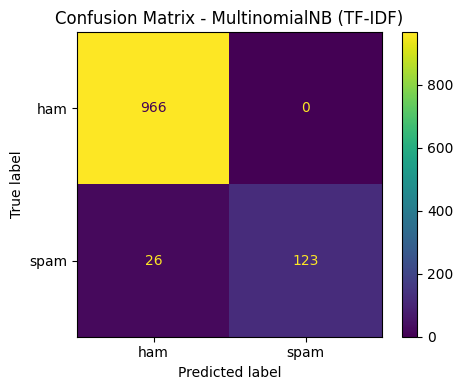

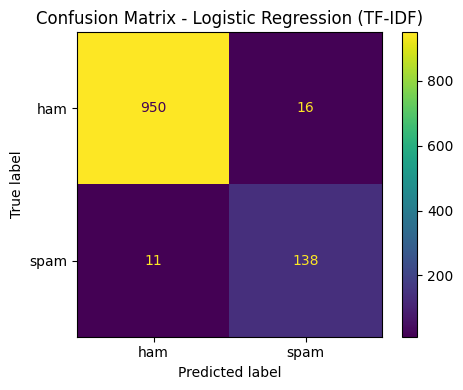

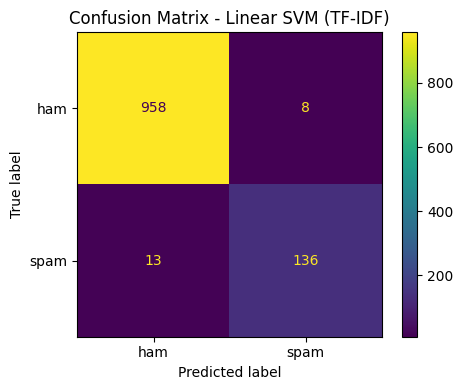

In [14]:
for name, model in fitted.items():
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=['ham','spam'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['ham','spam'])
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(ax=ax, values_format='d')
    ax.set_title(f'Confusion Matrix - {name}')
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"cm_{re.sub('[^a-zA-Z0-9]+','_',name).lower()}.png"), dpi=200)
    plt.show()

## 7. Best model + probability calibration
Linear SVM often performs extremely well for TF-IDF text features but does not output probabilities by default.
We calibrate it (Platt scaling / sigmoid) to get probability outputs for ROC/PR curves and threshold tuning.


In [15]:
best_base = models['Linear SVM (TF-IDF)']
calibrated = CalibratedClassifierCV(best_base, method='sigmoid', cv=3)
calibrated.fit(X_train, y_train)
pred = calibrated.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



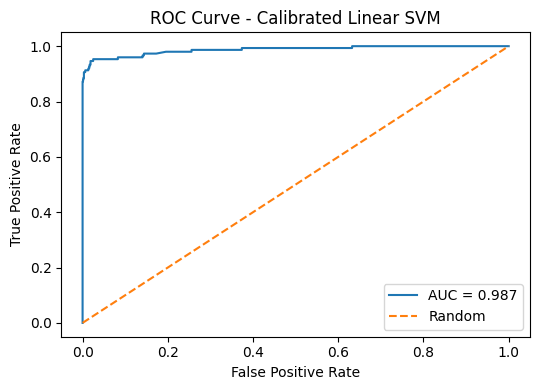

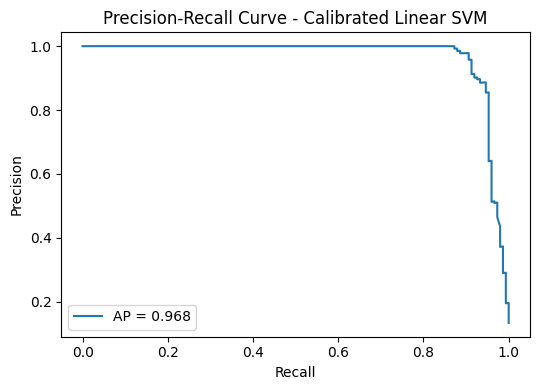

In [16]:
proba_spam = calibrated.predict_proba(X_test)[:, list(calibrated.classes_).index('spam')]
y_true = (y_test == 'spam').astype(int)

fpr, tpr, _ = roc_curve(y_true, proba_spam)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5.5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--',label='Random')
plt.title('ROC Curve - Calibrated Linear SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'roc_curve_svm_calibrated.png'), dpi=200)
plt.show()

prec, rec, _ = precision_recall_curve(y_true, proba_spam)
ap = average_precision_score(y_true, proba_spam)
plt.figure(figsize=(5.5,4))
plt.plot(rec, prec, label=f'AP = {ap:.3f}')
plt.title('Precision-Recall Curve - Calibrated Linear SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pr_curve_svm_calibrated.png'), dpi=200)
plt.show()

## 8. Explainability (interpretable model)
We use Logistic Regression coefficients to show which tokens are most indicative of spam vs ham.


In [17]:
lr = fitted['Logistic Regression (TF-IDF)']
tfidf = lr.named_steps['tfidf']
clf = lr.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]  # positive weights push prediction toward 'spam'

topk = 15
top_spam_idx = np.argsort(coefs)[-topk:][::-1]
top_ham_idx = np.argsort(coefs)[:topk]

top_spam = pd.DataFrame({'token': feature_names[top_spam_idx], 'weight': coefs[top_spam_idx]})
top_ham = pd.DataFrame({'token': feature_names[top_ham_idx], 'weight': coefs[top_ham_idx]})

display(top_spam)
display(top_ham)


,token,weight
0,txt,5.035269
1,uk,4.158818
2,mobile,4.073810
3,claim,3.822448
4,free,3.725219
5,www,3.685886
6,reply,3.466000
7,stop,3.296586
8,150p,3.228315
9,service,3.179916


,token,weight
0,ok,-2.283235
1,ll,-2.076648
2,da,-1.865619
3,home,-1.773075
4,got,-1.733149
5,gt,-1.721831
6,lt,-1.699604
7,come,-1.692453
8,lor,-1.583540
9,hey,-1.569590


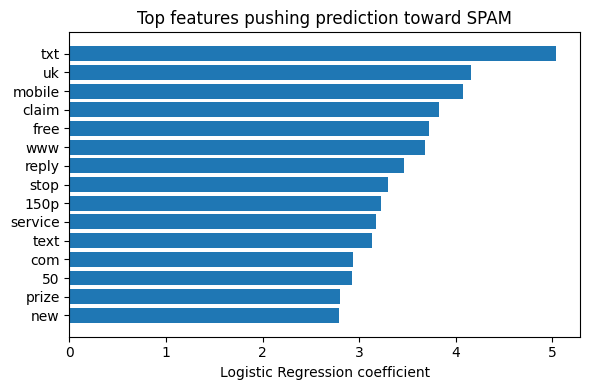

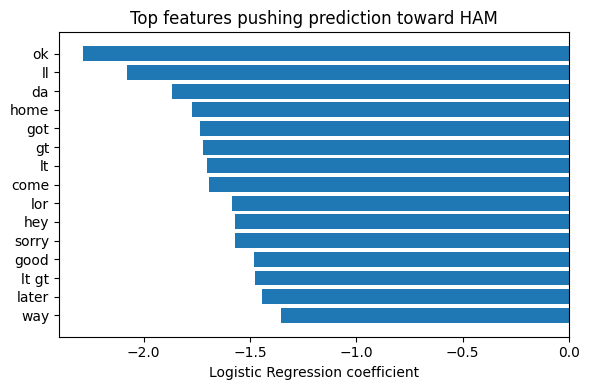

In [18]:
def barh(df_tokens, title, outname):
    plt.figure(figsize=(6,4))
    plt.barh(df_tokens['token'][::-1], df_tokens['weight'][::-1])
    plt.title(title)
    plt.xlabel('Logistic Regression coefficient')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, outname), dpi=200)
    plt.show()

barh(top_spam, 'Top features pushing prediction toward SPAM', 'top_features_spam.png')
barh(top_ham, 'Top features pushing prediction toward HAM', 'top_features_ham.png')


## 9. Error analysis
Inspect some false positives and false negatives to understand typical failure modes.


In [19]:
pred = calibrated.predict(X_test)
errors = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': pred})
fp = errors[(errors.true=='ham') & (errors.pred=='spam')].head(10)
fn = errors[(errors.true=='spam') & (errors.pred=='ham')].head(10)
fp, fn

(                                                  text true  pred
 197  .Please charge my mobile when you get up in mo...  ham  spam
 380           K..u also dont msg or reply to his msg..  ham  spam
 556                          Msg me when rajini comes.  ham  spam,
                                                   text  true pred
 122  Dear Voucher Holder 2 claim your 1st class air...  spam  ham
 165  Hi if ur lookin 4 saucy daytime fun wiv busty ...  spam  ham
 196                                 ringtoneking 84484  spam  ham
 219  Sorry I missed your call let's talk when you h...  spam  ham
 232  Rock yr chik. Get 100's of filthy films &XXX p...  spam  ham
 235  Latest News! Police station toilet stolen, cop...  spam  ham
 357  Bought one ringtone and now getting texts cost...  spam  ham
 362  Romantic Paris. 2 nights, 2 flights from £79 B...  spam  ham
 467  More people are dogging in your area now. Call...  spam  ham
 478  For sale - arsenal dartboard. Good condition b...  spam

## 10. Save the model (deployment-ready)
We save the full calibrated pipeline so it can be loaded and used directly.


In [20]:
MODEL_PATH = os.path.join(MODEL_DIR, 'spam_detector_calibrated_svm.joblib')
joblib.dump(calibrated, MODEL_PATH)
MODEL_PATH

'models/spam_detector_calibrated_svm.joblib'

## 11. Simple inference function


In [21]:
loaded = joblib.load(MODEL_PATH)
def predict_spam(message: str):
    proba = loaded.predict_proba([message])[0]
    labels = list(loaded.classes_)
    return {labels[i]: float(proba[i]) for i in range(len(labels))}

predict_spam('Congratulations! You have won a free prize. Call now!')

{'ham': 0.005978118167419222, 'spam': 0.9940218818325808}

## 12. Conclusion
This project demonstrates a complete NLP pipeline from raw text to a deployable classifier, including evaluation, explainability, and a deployment path.
